In [1]:
install.packages('qqman')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘calibrate’




In [3]:
library(data.table)
library(dplyr)
library(qqman)

In [4]:
blood <- fread('/mnt/project/vasilis/data/ebb/results_blood_clean/EM_202.2_mwas_assoc.csv')

In [5]:
brain <- fread('/mnt/project/vasilis/data/ebb/results_clean/EM_202.2_mwas_assoc.csv') 

In [56]:
bb <- fread('/mnt/project/vasilis/data/ebb/results_bb_clean/EM_202.2_mwas_assoc.csv') 

In [30]:
brain_leads <- fread('t2d_brain_lead.csv', header = F) %>% pull(V1)
blood_leads <- fread('t2d_blood_lead.csv', header = F) %>% pull(V1)
length(brain_leads)
length(blood_leads)

[1] 29

[1] 29

In [19]:
#' Creates a manhattan plot
#' 
#' Creates a manhattan plot from PLINK assoc output (or any data frame with 
#' chromosome, position, and p-value).
#' 
#' @param x A data.frame with columns "BP," "CHR," "P," and optionally, "SNP."
#' @param chr A string denoting the column name for the chromosome. Defaults to 
#'   PLINK's "CHR." Said column must be numeric. If you have X, Y, or MT 
#'   chromosomes, be sure to renumber these 23, 24, 25, etc.
#' @param bp A string denoting the column name for the chromosomal position. 
#'   Defaults to PLINK's "BP." Said column must be numeric.
#' @param p A string denoting the column name for the p-value. Defaults to 
#'   PLINK's "P." Said column must be numeric.
#' @param snp A string denoting the column name for the SNP name (rs number). 
#'   Defaults to PLINK's "SNP." Said column should be a character.
#' @param col A character vector indicating which colors to alternate.
#' @param chrlabs A character vector equal to the number of chromosomes
#'   specifying the chromosome labels (e.g., \code{c(1:22, "X", "Y", "MT")}).
#' @param suggestiveline Where to draw a "suggestive" line. Default 
#'   -log10(1e-5). Set to FALSE to disable.
#' @param genomewideline Where to draw a "genome-wide sigificant" line. Default 
#'   -log10(5e-8). Set to FALSE to disable.
#' @param highlight A character vector of SNPs in your dataset to highlight. 
#' @param highlight_col color to be used on highlighted SNPs
#'   These SNPs should all be in your dataset.
#' @param logp If TRUE, the -log10 of the p-value is plotted. It isn't very 
#'   useful to plot raw p-values, but plotting the raw value could be useful for
#'   other genome-wide plots, for example, peak heights, bayes factors, test 
#'   statistics, other "scores," etc.
#' @param annotatePval If set, SNPs below this p-value will be annotated on the plot. If logp is FALSE, SNPs above the specified value will be annotated.
#' @param annotateTop If TRUE, only annotates the top hit on each chromosome that is below the annotatePval threshold (or above if logp is FALSE). 
#' @param ... Arguments passed on to other plot/points functions
#'   
#' @return A manhattan plot.
#'   
#' @keywords visualization manhattan
#'   
#' @import utils
#' @import graphics
#' @import stats
#' 
#' @examples
#' manhattan(gwasResults)
#'   
#' @importFrom calibrate textxy  
#'   
#' @export

manhattan <- function(x, chr="CHR", bp="BP", p="P", snp="SNP", 
                      col=c("gray10", "gray60"), chrlabs=NULL,
                      suggestiveline=-log10(1e-5), genomewideline=-log10(5e-8), 
                      highlight=NULL, highlight_col = 'royalblue3', logp=TRUE, annotatePval = NULL, annotateTop = TRUE, ...) {

    # Not sure why, but package check will warn without this.
    CHR=BP=P=index=NULL
    
    # Check for sensible dataset
    ## Make sure you have chr, bp and p columns.
    if (!(chr %in% names(x))) stop(paste("Column", chr, "not found!"))
    if (!(bp %in% names(x))) stop(paste("Column", bp, "not found!"))
    if (!(p %in% names(x))) stop(paste("Column", p, "not found!"))
    ## warn if you don't have a snp column
    if (!(snp %in% names(x))) warning(paste("No SNP column found. OK unless you're trying to highlight."))
    ## make sure chr, bp, and p columns are numeric.
    if (!is.numeric(x[[chr]])) stop(paste(chr, "column should be numeric. Do you have 'X', 'Y', 'MT', etc? If so change to numbers and try again."))
    if (!is.numeric(x[[bp]])) stop(paste(bp, "column should be numeric."))
    if (!is.numeric(x[[p]])) stop(paste(p, "column should be numeric."))
    
    # Create a new data.frame with columns called CHR, BP, and P.
    # d=data.frame(CHR=x[[chr]], BP=x[[bp]], P=x[[p]], pos = NA, index = NA) # with millions of SNPs, create dataframe at once 
	                                                         #  rather than dynamically allocated(see line 72-73, and remove line 87 and line 91 )
    
    # If the input data frame has a SNP column, add it to the new data frame you're creating.
    if (!is.null(x[[snp]])) d = data.frame(CHR=x[[chr]], BP=x[[bp]], P=x[[p]], pos = NA, index = NA ,SNP=x[[snp]], stringsAsFactors = FALSE) else 
	    d = data.frame(CHR=x[[chr]], BP=x[[bp]], P=x[[p]], pos = NA, index = NA)
	    
    
    # Set positions, ticks, and labels for plotting
    ## Sort and keep only values where is numeric.
    #d <- subset(d[order(d$CHR, d$BP), ], (P>0 & P<=1 & is.numeric(P)))
    #  d <- subset(d, (is.numeric(CHR) & is.numeric(BP) & is.numeric(P)))       ## unused, all three variables are numeric, line:63-65 
    d <- d[order(d$CHR, d$BP), ]
    #d$logp <- ifelse(logp, yes=-log10(d$P), no=d$P)
    if (logp) {
        d$logp <- -log10(d$P)
    } else {
        d$logp <- d$P
    }
   # d$pos=NA
    
    
    # Fixes the bug where one chromosome is missing by adding a sequential index column.
   # d$index=NA
   # ind = 0
   # for (i in unique(d$CHR)){
   #     ind = ind + 1
   #     d[d$CHR==i,]$index = ind
   # }
   d$index = rep.int(seq_along(unique(d$CHR)), times = tapply(d$SNP,d$CHR,length))  # replcace the for loop of line 92-96 to improve efficiency
    
    # This section sets up positions and ticks. Ticks should be placed in the
    # middle of a chromosome. The a new pos column is added that keeps a running
    # sum of the positions of each successive chromsome. For example:
    # chr bp pos
    # 1   1  1
    # 1   2  2
    # 2   1  3
    # 2   2  4
    # 3   1  5
    nchr = length(unique(d$CHR))
    if (nchr==1) { ## For a single chromosome
        ## Uncomment the next two linex to plot single chr results in Mb
        #options(scipen=999)
	    #d$pos=d$BP/1e6
        d$pos=d$BP
      #  ticks=floor(length(d$pos))/2+1          ## unused, from code line: 169
        xlabel = paste('Chromosome',unique(d$CHR),'position')
      #  labs = ticks          ## unused, from code line: 169
    } else { ## For multiple chromosomes
        lastbase=0
        ticks=NULL
        for (i in unique(d$index)) {
            if (i==1) {
                d[d$index==i, ]$pos=d[d$index==i, ]$BP
            } else {
		## chromosome position maybe not start at 1, eg. 9999. So gaps may be produced. 
		lastbase = lastbase +max(d[d$index==(i-1),"BP"])   # replace line 128
		d[d$index == i,"BP"] = d[d$index == i,"BP"]-min(d[d$index==i,"BP"]) +1
		d[d$index == i, "pos"] = d[d$index == i,"BP"] + lastbase    # replace line 129
                # lastbase=lastbase+tail(subset(d,index==i-1)$BP, 1)
                # d[d$index==i, ]$pos=d[d$index==i, ]$BP+lastbase
		   
            }
            # Old way: assumes SNPs evenly distributed
            # ticks=c(ticks, d[d$index==i, ]$pos[floor(length(d[d$index==i, ]$pos)/2)+1])
            # New way: doesn't make that assumption
           # ticks = c(ticks, (min(d[d$index == i,]$pos) + max(d[d$index == i,]$pos))/2 + 1)  # see line 136, to reduce the burden of for loop 
        }
	ticks <-tapply(d$pos,d$index,quantile,probs=0.5)   # replace line 135
        xlabel = 'Chromosome'
        #labs = append(unique(d$CHR),'') ## I forgot what this was here for... if seems to work, remove.
        labs <- unique(d$CHR)
    }
    
    # Initialize plot
    xmax = ceiling(max(d$pos) * 1.03)
    xmin = floor(max(d$pos) * -0.03)
    
    # The old way to initialize the plot
    # plot(NULL, xaxt='n', bty='n', xaxs='i', yaxs='i', xlim=c(xmin,xmax), ylim=c(ymin,ymax),
    #      xlab=xlabel, ylab=expression(-log[10](italic(p))), las=1, pch=20, ...)

    
    # The new way to initialize the plot.
    ## See http://stackoverflow.com/q/23922130/654296
    ## First, define your default arguments
    def_args <- list(xaxt='n', bty='n', xaxs='i', yaxs='i', las=1, pch=20,
                     xlim=c(xmin,xmax), ylim=c(0,ceiling(max(d$logp))),
                     xlab=xlabel, ylab=expression(-log[10](italic(p))))
    ## Next, get a list of ... arguments
    #dotargs <- as.list(match.call())[-1L]
    dotargs <- list(...)
    ## And call the plot function passing NA, your ... arguments, and the default
    ## arguments that were not defined in the ... arguments.
    do.call("plot", c(NA, dotargs, def_args[!names(def_args) %in% names(dotargs)]))
    
    # If manually specifying chromosome labels, ensure a character vector and number of labels matches number chrs.
    if (!is.null(chrlabs)) {
        if (is.character(chrlabs)) {
            if (length(chrlabs)==length(labs)) {
                labs <- chrlabs
            } else {
                warning("You're trying to specify chromosome labels but the number of labels != number of chromosomes.")
            }
        } else {
            warning("If you're trying to specify chromosome labels, chrlabs must be a character vector")
        }
    }
    
    # Add an axis. 
    if (nchr==1) { #If single chromosome, ticks and labels automatic.
        axis(1, ...)
    } else { # if multiple chrs, use the ticks and labels you created above.
        axis(1, at=ticks, labels=labs, ...)
    }
    
    # Create a vector of alternatiting colors
    #col=rep(col, max(d$CHR))  # replaced by line 187
    col = rep_len(col, max(d$index))  ## mean this one?  the results are same

    # Add points to the plot
    if (nchr==1) {
        with(d, points(pos, logp, pch=20, col=col[1], ...))
    } else {
        # if multiple chromosomes, need to alternate colors and increase the color index (icol) each chr.
        icol=1
        for (i in unique(d$index)) {
            #with(d[d$index==unique(d$index)[i], ], points(pos, logp, col=col[icol], pch=20, ...))
	    points(d[d$index==i,"pos"], d[d$index==i,"logp"], col=col[icol], pch=20, ...)
            icol=icol+1
        }
    }
    
    # Add suggestive and genomewide lines
    if (suggestiveline) abline(h=suggestiveline, col="blue")
    if (genomewideline) abline(h=genomewideline, col="red")
    
    # Highlight snps from a character vector
    if (!is.null(highlight)) {
        if (any(!(highlight %in% d$SNP))) warning("You're trying to highlight SNPs that don't exist in your results.")
        d.highlight=d[which(d$SNP %in% highlight), ]
        with(d.highlight, points(pos, logp, col=highlight_col, pch=20, ...)) 
    }
    
    # Highlight top SNPs
    if (!is.null(annotatePval)) {
        # extract top SNPs at given p-val
        if (logp) {
            topHits = subset(d, P <= annotatePval)
        } else
            topHits = subset(d, P >= annotatePval)
        par(xpd = TRUE)
        # annotate these SNPs
        if (annotateTop == FALSE) {
          if (logp) {
              with(subset(d, P <= annotatePval), 
                   textxy(pos, -log10(P), offset = 0.625, labs = topHits$SNP, cex = 0.45), ...)
          } else
              with(subset(d, P >= annotatePval), 
                   textxy(pos, P, offset = 0.625, labs = topHits$SNP, cex = 0.45), ...)
        }
        else {
            # could try alternative, annotate top SNP of each sig chr
            topHits <- topHits[order(topHits$P),]
            topSNPs <- NULL
            
            for (i in unique(topHits$CHR)) {
                
                chrSNPs <- topHits[topHits$CHR == i,]
                topSNPs <- rbind(topSNPs, chrSNPs[1,])
                
            }
            if (logp ){
                textxy(topSNPs$pos, -log10(topSNPs$P), offset = 0.625, labs = topSNPs$SNP, cex = 0.5, ...)
            } else
              textxy(topSNPs$pos, topSNPs$P, offset = 0.625, labs = topSNPs$SNP, cex = 0.5, ...)
        }
    }  
    par(xpd = FALSE)
}

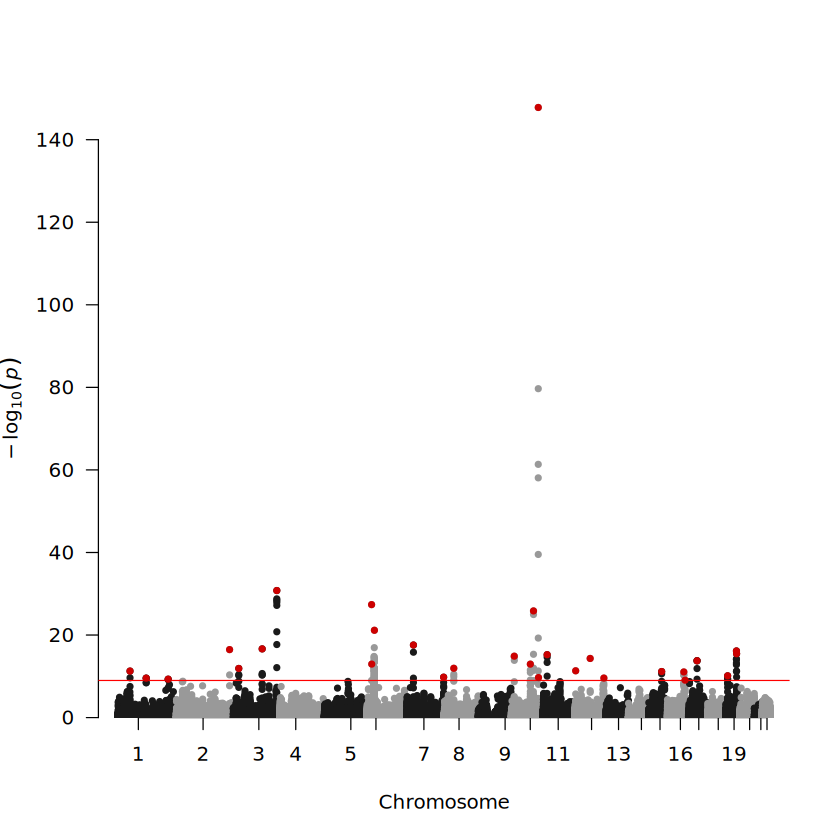

In [57]:
thres = 0.05 / (nrow(blood) * 445)

manhattan( 
    blood,
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    highlight = blood_leads,
    highlight_col = 'red3',
    ylim = c(0,150)
)

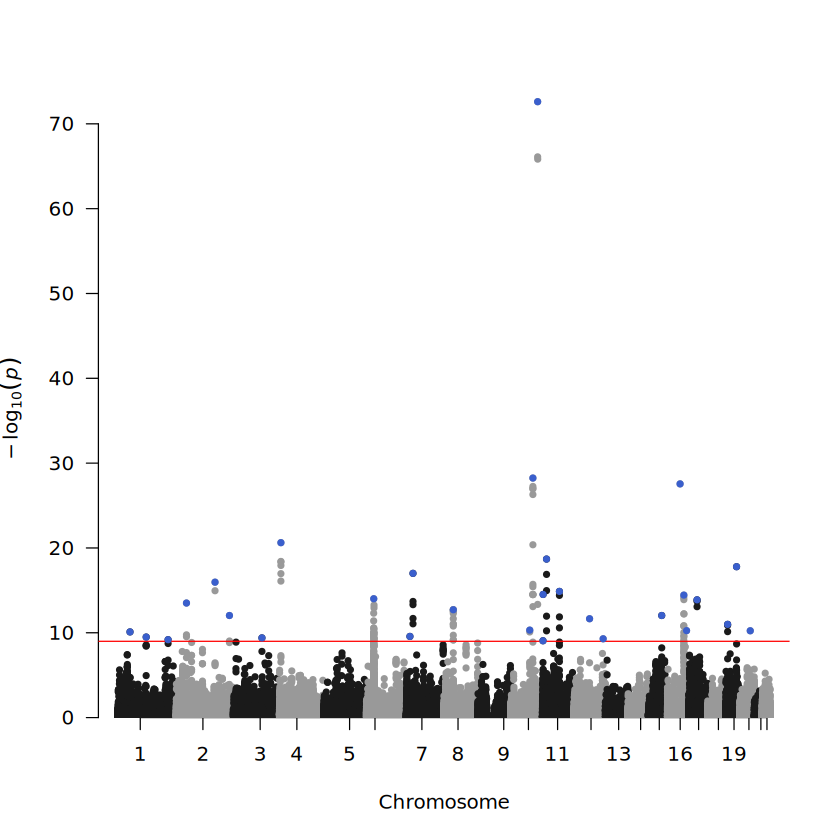

In [28]:
manhattan(
    brain,
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    highlight = brain_leads,
    highlight_col = 'royalblue3'
)

Warning message in manhattan(bb, snp = "cpg", chr = "chr", p = "pvalue_x1", bp = "pos", :
“You're trying to highlight SNPs that don't exist in your results.”


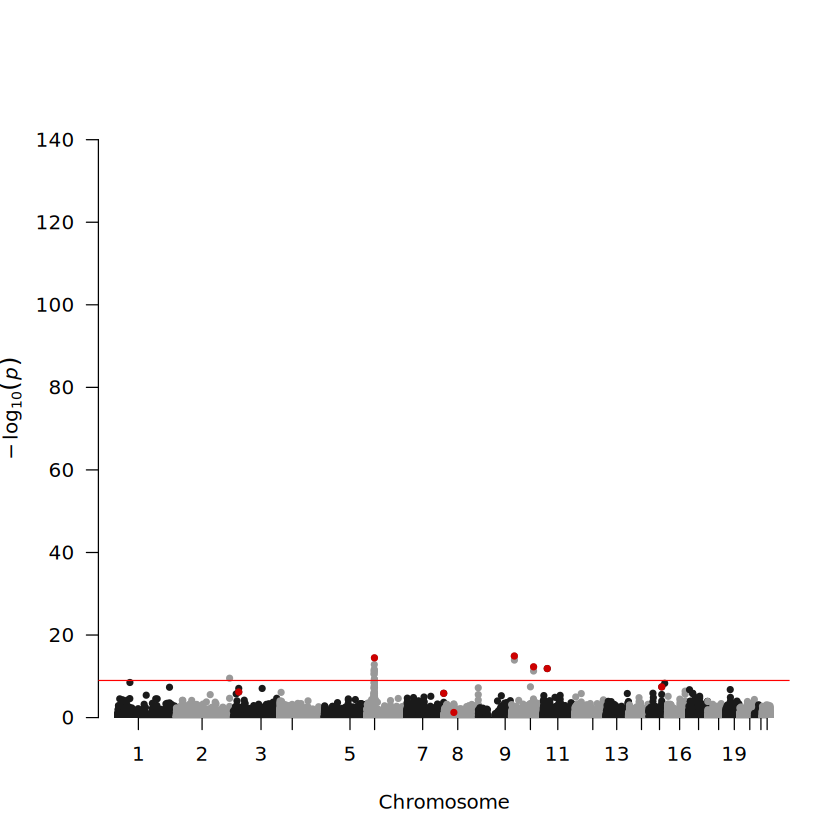

In [65]:
manhattan( 
    bb,
    snp = 'cpg', chr = 'chr', p = 'pvalue_x1', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    highlight = blood_leads,
    highlight_col = 'red3',
    ylim = c(0,150)
)

Warning message in manhattan(bb, snp = "cpg", chr = "chr", p = "pvalue_x2", bp = "pos", :
“You're trying to highlight SNPs that don't exist in your results.”


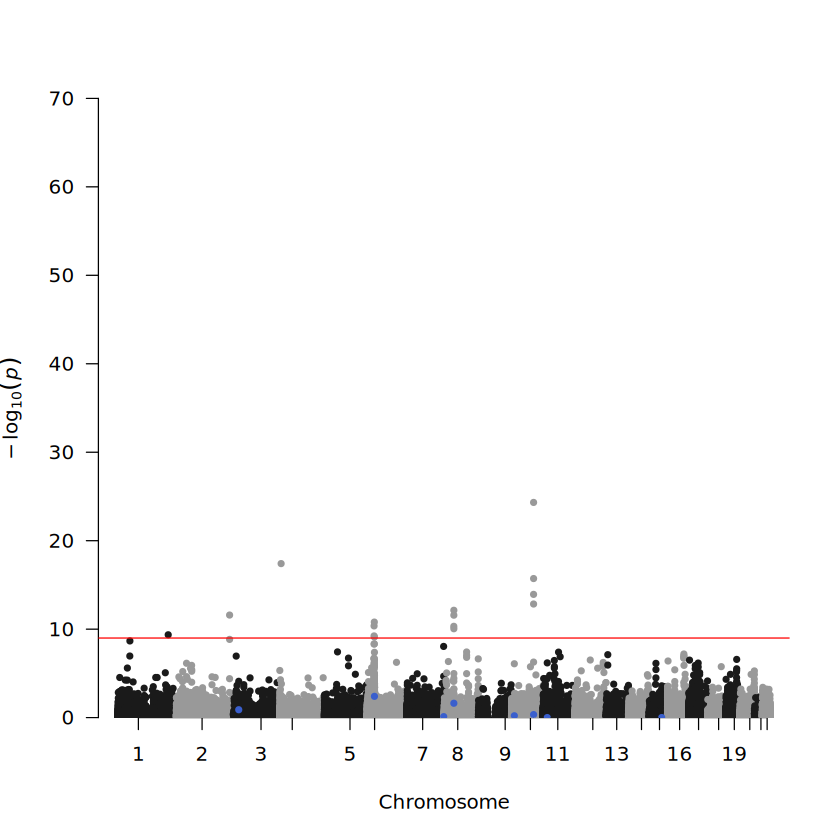

In [62]:
manhattan( 
    bb,
    snp = 'cpg', chr = 'chr', p = 'pvalue_x2', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    highlight = brain_leads,
    highlight_col = 'royalblue3',
    ylim = c(0,70)
)

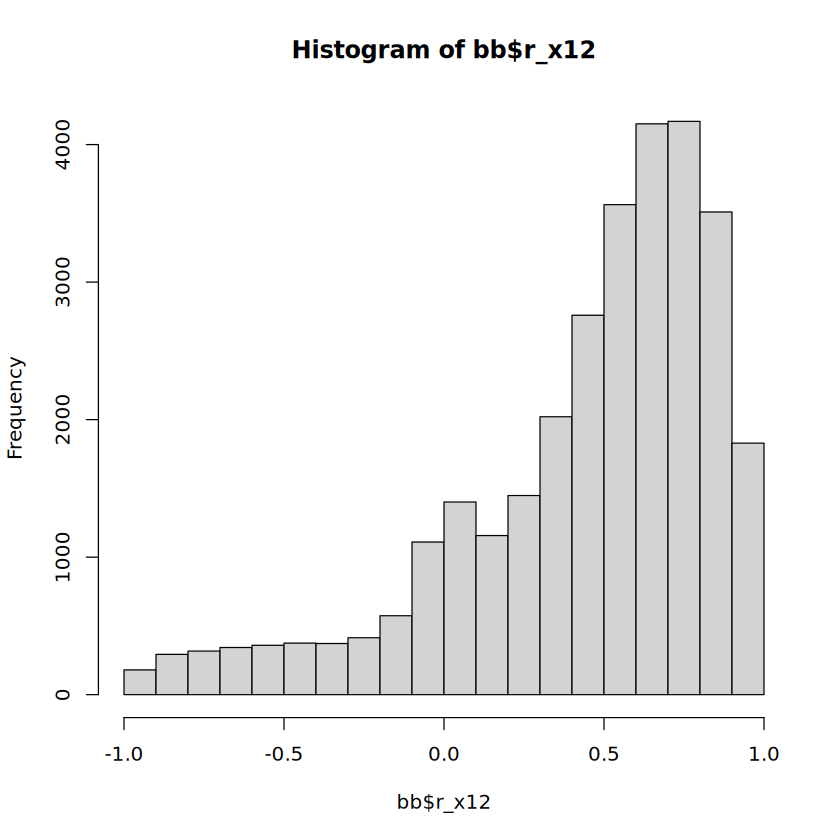

In [68]:
hist(bb$r_x12)

[1] 30283

[1] 0.4865586

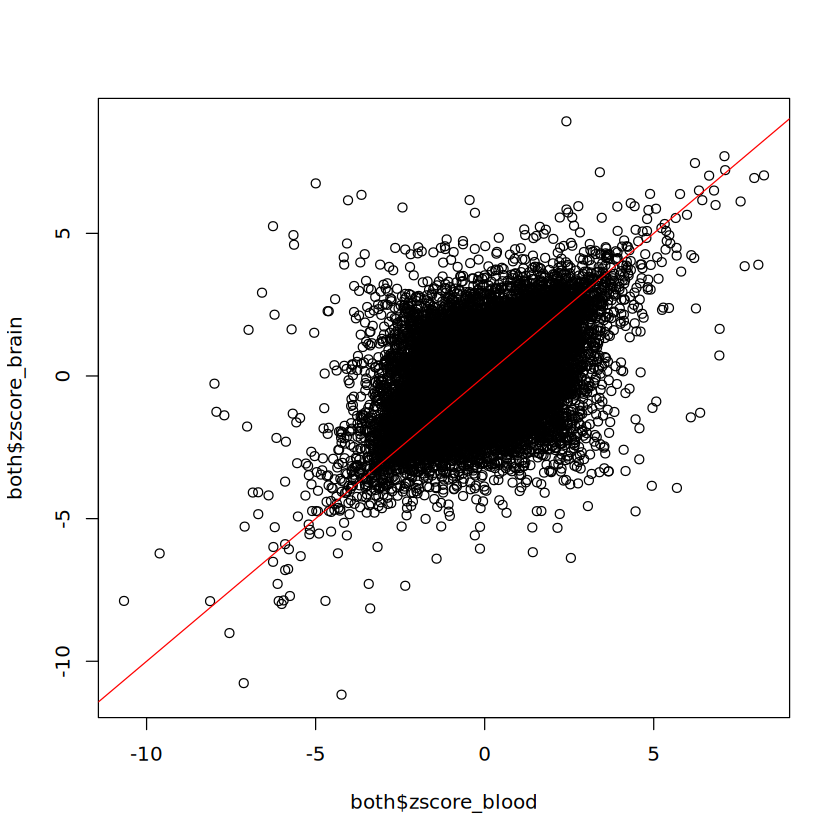

In [27]:
both <- inner_join(brain, blood, by = 'cpg', suffix = c('_brain', '_blood')) # %>% filter(pvalue_blood < thres)
nrow(both)
plot(both$zscore_blood, both$zscore_brain)
abline(a = 0, b = 1, col = 'red' )
cor(both$zscore_blood, both$zscore_brain)

[1] 0.2208964

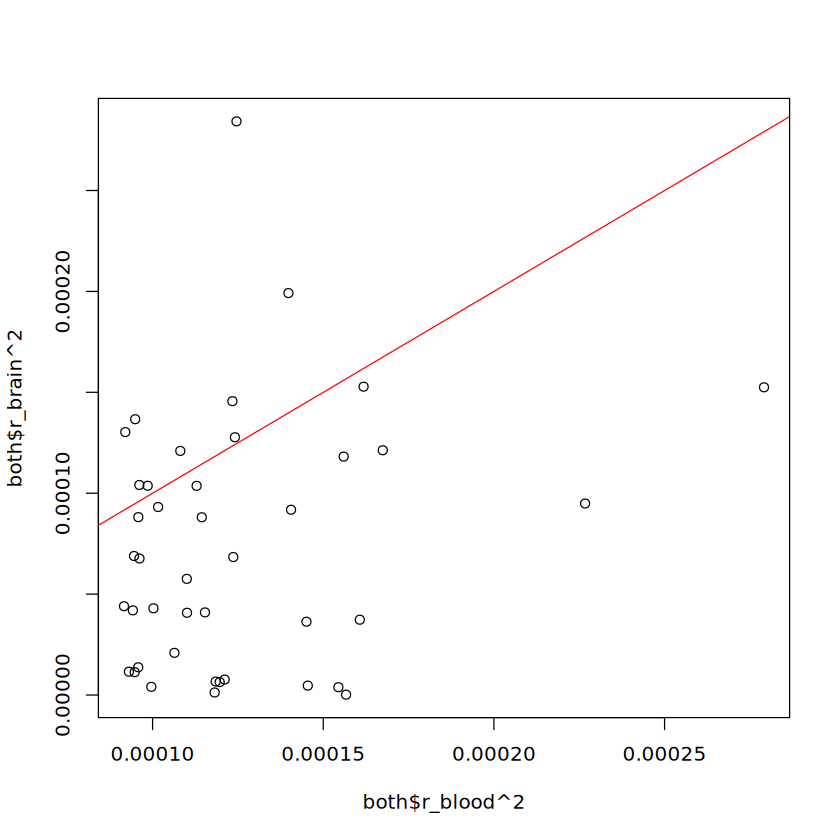

In [23]:
both <- inner_join(brain, blood, by = 'cpg', suffix = c('_brain', '_blood'))  %>% filter(pvalue_blood < thres)
plot(both$r_blood^2, both$r_brain^2)
abline(a = 0, b = 1, col = 'red' )
cor(both$r_blood^2, both$r_brain^2)

In [5]:
# both %>% filter(pvalue_brain < thres)

In [10]:
brain$cpg %>% length
blood$cpg %>% length
intersect(brain$cpg, blood$cpg) %>% length

[1] 99106

[1] 111454

[1] 30283

In [11]:
del_blood <- fread('MB_308.1_mwas_assoc.csv')

In [12]:
del_brain <- fread('/mnt/project/vasilis/data/ebb/results_clean/MB_308.1_mwas_assoc.csv') 

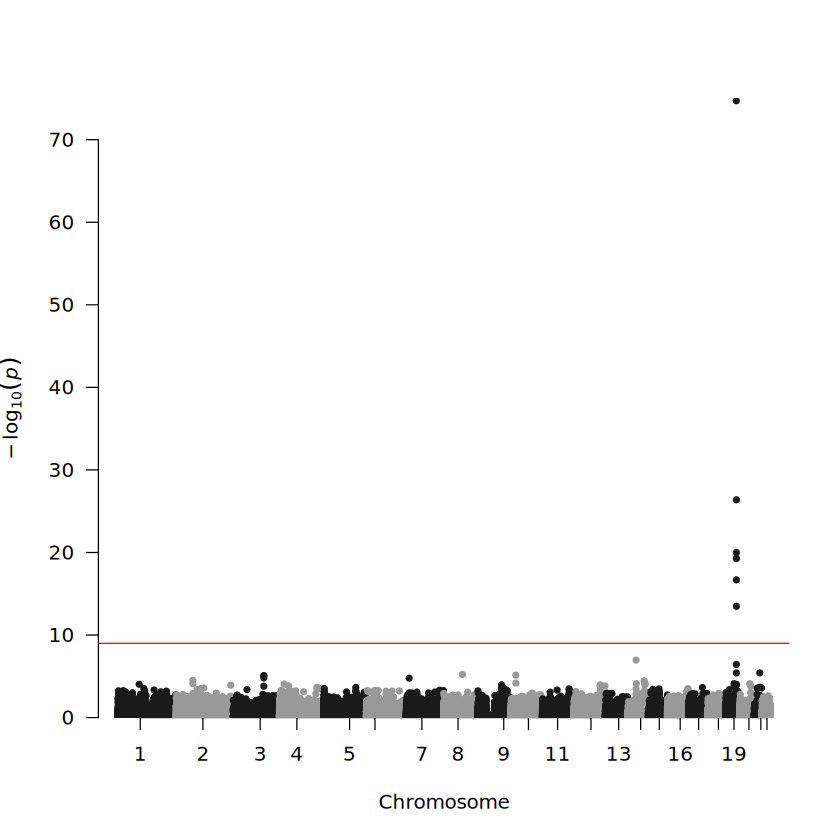

In [13]:
manhattan(
    del_brain,
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    annotateTop = TRUE
)

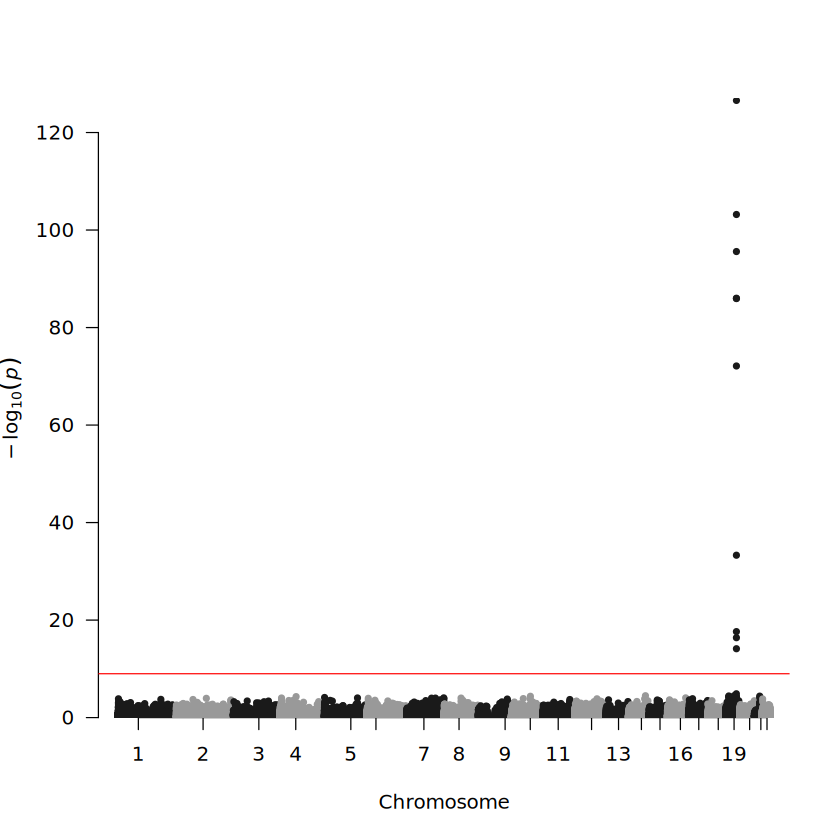

In [14]:
manhattan(
    del_blood,
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    annotateTop = TRUE
)

[1] 0.04525332

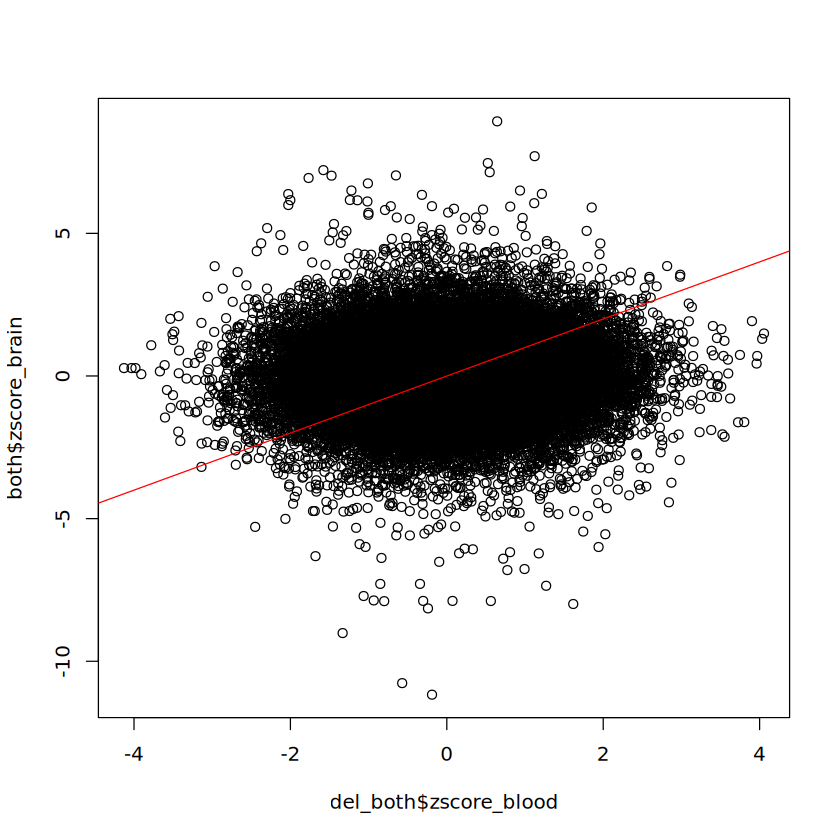

In [15]:
del_both <- inner_join(del_brain, del_blood, by = 'cpg', suffix = c('_brain', '_blood'))
plot(del_both$zscore_blood, both$zscore_brain)
abline(a = 0, b = 1, col = 'red' )
cor(del_both$zscore_blood, both$zscore_brain)

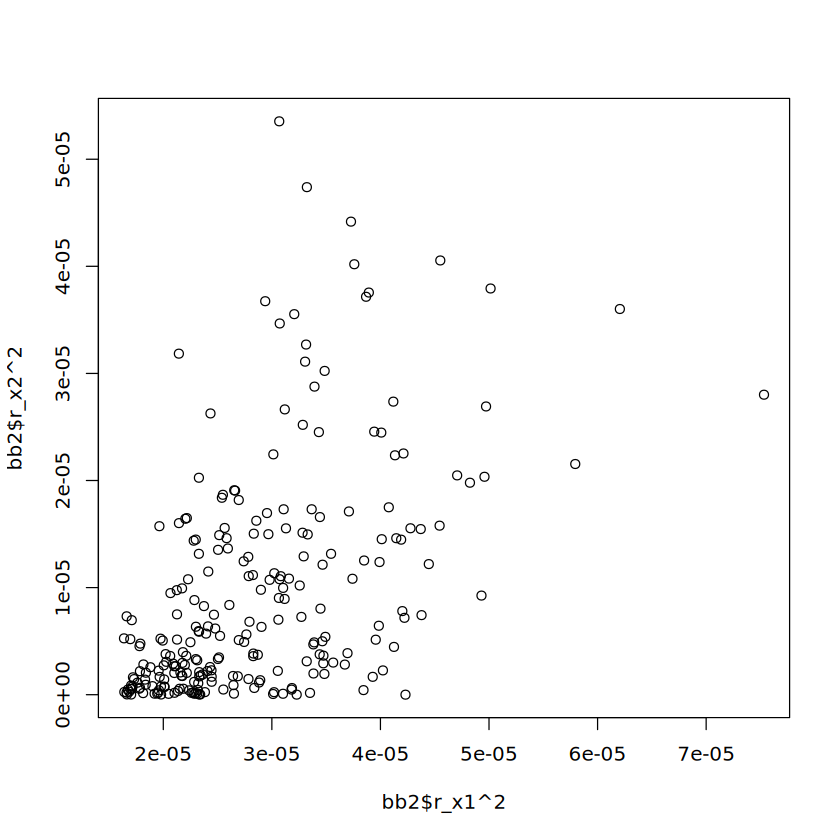

In [33]:
bb2 <- bb %>% filter(r_x12^2 < 0.5 & pvalue_x1 < 0.01) 
plot(bb2$r_x1^2, bb2$r_x2^2)

In [45]:
bb2 <- bb %>% filter(r_x12^2 < 0.5) 
bb2 %>% filter(r_x1^2 > r_x2^2)  %>% nrow # x1: blood-based; x2: brain-based
bb2 %>% filter(r_x1^2 <= r_x2^2)  %>% nrow 

[1] 10117

[1] 10257